In [1]:
from langgraph.graph import START, END , StateGraph
from typing import TypedDict,Literal

In [2]:
class QuadraticEqation(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str


In [3]:
def showEquation(state:QuadraticEqation):
    equation = f"{state['a']}x2{state['b']}x{state['c']}"
    return {'equation':equation}


In [4]:
def calcuate_discriminant(state:QuadraticEqation):
    discriminant = (state['b'])**2-4*(state['a']*state['c'])
    return {'discriminant':discriminant} 

In [5]:
def real_roots(state: QuadraticEqation):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

def repeated_roots(state: QuadraticEqation):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

def no_real_roots(state: QuadraticEqation):

    result = 'No real roots'

    return {'result': result}

In [6]:
def check_condition(state:QuadraticEqation)->Literal['real_roots','repeated_roots','no_real_roots']:
    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [12]:
graph = StateGraph(QuadraticEqation)

graph.add_node('show_equation',showEquation)
graph.add_node('calcualate_discriminant',calcuate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calcualate_discriminant')
graph.add_conditional_edges('calcualate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()


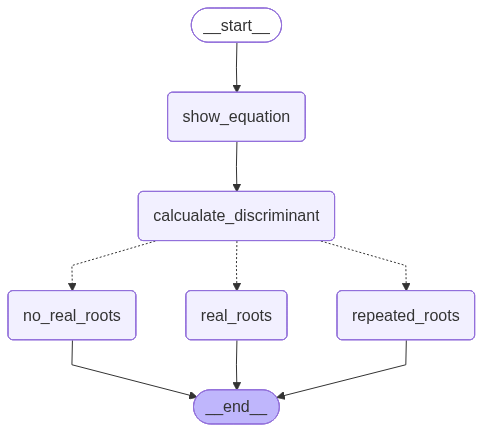

In [13]:
workflow


In [15]:
intial_state={
    'a':2,
    'b':15,
    'c':10
}

workflow.invoke(intial_state)

{'a': 2,
 'b': 15,
 'c': 10,
 'equation': '2x215x10',
 'discriminant': 145,
 'result': 'The roots are -0.7396013553019261 and -6.760398644698074'}